In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from pathlib import Path
import os

print("Current folder:", os.getcwd())

print("\nFiles here:")
for f in os.listdir():
    print(f)

print("\nCSV files found recursively:")
for p in Path(".").rglob("*.csv"):
    print(p.resolve())

Current folder: c:\Users\manas\Downloads\machine_learning

Files here:
.git
.gitignore
cleaned_house_prices.csv
data.csv
data.json
gradient_decent.py
homeprice.csv
house_prices.csv
linearreg.ipynb
linregmultivariable.ipynb
matplotlib_learning.py
notes
numpy_learning.py
pandas_learning.py
README.md
seaborn.ipynb

CSV files found recursively:
C:\Users\manas\Downloads\machine_learning\cleaned_house_prices.csv
C:\Users\manas\Downloads\machine_learning\data.csv
C:\Users\manas\Downloads\machine_learning\homeprice.csv
C:\Users\manas\Downloads\machine_learning\house_prices.csv


In [3]:
df = pd.read_csv("data.csv")
df

,number,name,type1,type2,height,weight,legendary
0,1,Bulbasaur,Grass,Poison,0.7,6.9,False
1,2,Ivysaur,Grass,Poison,1.0,13.0,False
2,3,Venusaur,Grass,Poison,2.0,100.0,False
3,4,Charmander,Fire,NaN,0.6,8.5,False
4,5,Charmeleon,Fire,NaN,1.1,19.0,False
5,6,Charizard,Fire,Flying,1.7,90.5,False
6,7,Squirtle,Water,NaN,0.5,9.0,False
7,8,Wartortle,Water,NaN,1.0,22.5,False
8,9,Blastoise,Water,NaN,1.6,85.5,False
9,10,Caterpie,Bug,NaN,0.3,2.9,False


Text(0, 0.5, 'weight')

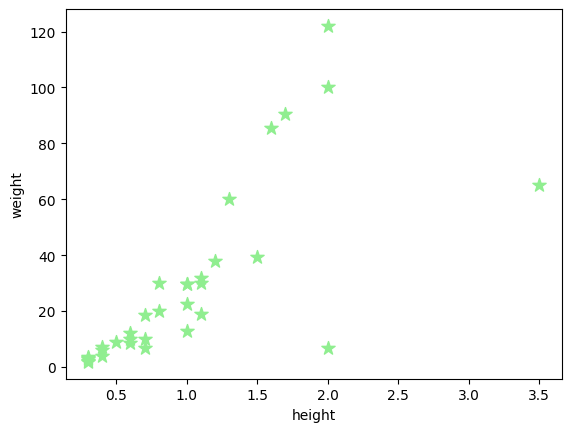

In [4]:
%matplotlib inline
plt.scatter(df["height"], df["weight"], color="lightgreen", marker="*", s=100)
plt.xlabel("height")
plt.ylabel("weight")

In [5]:
#Craete an object for regression model and fit the data in it
reg = linear_model.LinearRegression()
reg.fit(df[["height"]], df["weight"]) #First is 2D array and second is 1D array

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
# reg.predict(170) #This will give error because it is expecting 2D array
reg.predict([[2.7]]) #This will work because it is 2D array

C:\Users\manas\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([85.78749098])

In [23]:
reg.coef_ #This will give the value of m in y = mx + c

array([33.62144232])

In [24]:
reg.intercept_

np.float64(-4.990403271065492)

In [7]:
#Without entering 2D array input
def predict_value(x):
    return reg.predict([[x]])

print(predict_value(2.7))

reg.predict(np.array([2.8]).reshape(1, -1))

[85.78749098]


C:\Users\manas\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\manas\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([89.14963521])

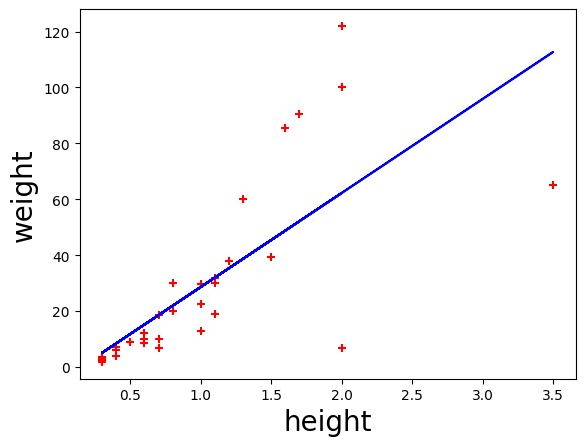

In [8]:
%matplotlib inline
plt.xlabel('height', fontsize=20)
plt.ylabel('weight', fontsize=20)
plt.scatter(df.height, df.weight, color='red', marker='+')
plt.plot(df.height, reg.predict(df[["height"]]), color='blue')